# Aktywacja Strategii Odbicie Ogórkowe
Ten notatnik służy do testowania, wizualizacji i optymalizacji strategii powrotu do średniej po mocnych spadkach.

## Imports & ładowanie

In [3]:
import os
import sys

# Dodajemy folder glowny do path aby moduly dzialaly
sys.path.append(os.path.abspath('d:/Antigravity/rebound/lyse-lby'))
os.chdir('d:/Antigravity/rebound/lyse-lby')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Importujemy ladowanie danych i nasze nowe moduly
from maciex_py.ladowanie_danych import create_stock_dfs
from odbicie.mackowe_sygnaly import mackowe_sygnaly
from odbicie.odbicie import generate_odbicie_entries
from odbicie.tbm import moving_triple_barrier_labels

# Ustawienia ładowania danych
settings = {
    'market': 'stocks',
    'interval': '1week',
    'vol_enabled': True,
    'vol_ratio_window': 20,
    'vol_ratio_threshold': 1.2,
    'cmo_enabled': True,
    'cmo_len': 6,
    'cmo_thres': -35,
    'cmo_thres_prev': -50
}

In [4]:
# 1. Ładowanie Danych
print("Ładowanie danych dziennych i tygodniowych...")
dfs_1d, dfs_1w = create_stock_dfs(settings)
print(f"Załadowano {len(dfs_1d)} symboli 1D i {len(dfs_1w)} symboli 1W.")

Ładowanie danych dziennych i tygodniowych...


Loading data:   0%|          | 0/479 [00:00<?, ?it/s]

Załadowano 478 symboli 1D i 478 symboli 1W.


## Generowanie sygnałów bazowych

In [5]:
# 2. Generowanie Sygnałów Bazowych (mackowe_sygnaly)
signals_df = mackowe_sygnaly(
    dfs=dfs_1w,
    settings=settings,
    require_vol_confirmation=True,
    require_cmo_confirmation=True,
    interval='1w',
    entry_offset=0,
    pattern_cols=['hammer', 'inverted_hammer', 'engulfing_bull', 'piercing_line'],
    debug=True
)
signals_df.describe()

📡 Scanning 1w signals: 100%|██████████| 478/478 [00:58<00:00,  8.14it/s]

✅ Found 912 signals. Debug summary:
  no_pattern_found: 0
  vol_reject: 9464
  cmo_reject: 2011
  entry_oob: 0


,signal_time,entry_time,signal_close
count,912,912,912.000000
mean,2023-10-08 09:01:34.736842,2023-10-08 09:01:34.736842,129.103488
min,2021-07-25 00:00:00,2021-07-25 00:00:00,7.970000
25%,2022-05-15 00:00:00,2022-05-15 00:00:00,51.740002
50%,2023-10-08 00:00:00,2023-10-08 00:00:00,97.340000
75%,2025-03-16 00:00:00,2025-03-16 00:00:00,179.127495
max,2026-02-22 00:00:00,2026-02-22 00:00:00,565.369995
std,NaN,NaN,103.256636


## Wejście i Wyjście

In [6]:
# 3. Wejście na podstawie progu (Odbicie Ogórkowe)
threshold_pct = 0.11  # 3% spadek od zamknięcia świecy sygnałowej

entries_df = generate_odbicie_entries(
    signals_df=signals_df,
    market_data_daily=dfs_1d,
    threshold_pct=threshold_pct,
    max_setup_hold_bars=10
)
print(f"Wygenerowano {len(entries_df)} wejść przy progu {threshold_pct*100}%")
entries_df.head()

Wygenerowano 107 wejść przy progu 11.0%


,symbol,signal_time,pattern,entry_time,entry_price,signal_close,threshold_pct,entry_atr
0,ABNB,2022-06-19,hammer,2022-06-30,88.546098,99.489998,0.11,6.897889
1,ALB,2023-11-05,hammer,2023-11-09,113.902203,127.980003,0.11,7.207769
2,ALB,2023-10-29,inverted_hammer,2023-11-01,119.651602,134.440002,0.11,7.000488
3,ARE,2025-11-23,hammer,2025-12-08,45.292099,50.889999,0.11,2.208598
4,AXP,2025-03-23,engulfing_bull,2025-04-04,237.919998,270.510010,0.11,10.113220


In [ ]:
entries_df['wait_time'] = entries_df['entry_time'] - entries_df['signal_time']
entries_df['wait_time'].describe()


count                       107
mean     7 days 17:43:10.654205
std      3 days 17:23:44.315583
min             1 days 00:00:00
25%             4 days 00:00:00
50%             8 days 00:00:00
75%            11 days 00:00:00
max            15 days 00:00:00
Name: wait_time, dtype: object

<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\s'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\s'
C:\Users\PC\AppData\Local\Temp\ipykernel_13984\3964389735.py:35: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x, p_scaled, 'k', linewidth=2, label=f'Normal Distribution\n$\mu={mu:.2f}$, $\sigma={std:.2f}$')
C:\Users\PC\AppData\Local\Temp\ipykernel_13984\3964389735.py:35: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x, p_scaled, 'k', linewidth=2, label=f'Normal Distribution\n$\mu={mu:.2f}$, $\sigma={std:.2f}$')


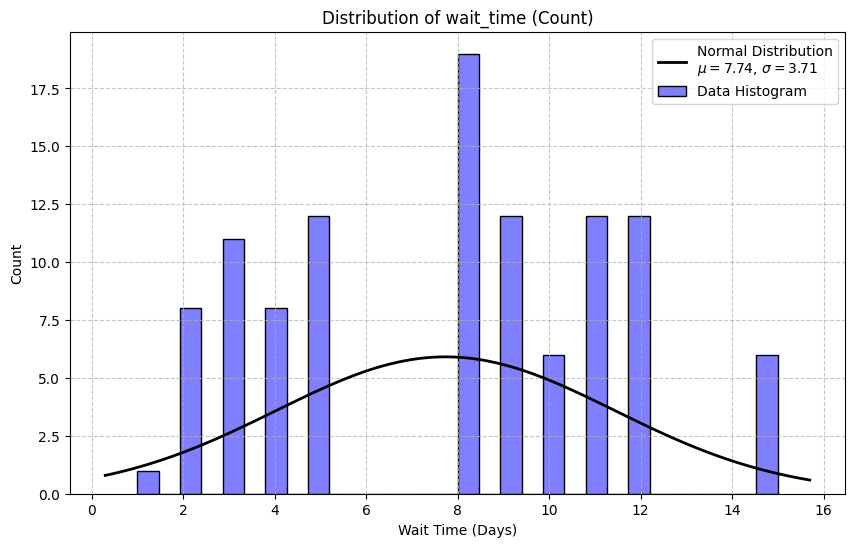

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import numpy as np
import pandas as pd

# 1. Clean data: Drop NaN values from wait_time
if pd.api.types.is_timedelta64_dtype(entries_df['wait_time']):
    wait_time_data = entries_df['wait_time'].dt.total_seconds() / (24 * 3600)  # Convert to days
else:
    wait_time_data = entries_df['wait_time'].dropna()''

plt.figure(figsize=(10, 6))

bins = 30
# 2. Plot the histogram of the data using count
# stat='count' is default, but we specify it for clarity
ax = sns.histplot(wait_time_data, bins=bins, stat='count', alpha=0.5, color='blue', label='Data Histogram')

# 3. Fit a normal distribution (bell curve) to the wait_time_data
mu, std = norm.fit(wait_time_data)

# 4. Create the x-axis values for the bell curve line
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

# 5. Scale the bell curve (pdf) to match the count histogram
# Formula: Scale factor = (Total Count) * (Bin Width)
bin_width = (xmax - xmin) / bins
scale_factor = len(wait_time_data) * bin_width
p_scaled = p * scale_factor

# 6. Plot the scaled bell curve
plt.plot(x, p_scaled, 'k', linewidth=2, label=f'Normal Distribution\n$\mu={mu:.2f}$, $\sigma={std:.2f}$')

plt.title('Distribution of wait_time (Count)')
plt.xlabel('Wait Time (Days)')
plt.ylabel('Count')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [21]:
# 4. Wyjście z użyciem Moving Triple Barrier Method
trades_df = moving_triple_barrier_labels(
    entries_df=entries_df,
    market_data_daily=dfs_1d,
    tp_mult=2,            # Zysk to 2x ATR (lub 4%)
    sl_mult=2,            # Strata to 1x ATR (lub 2%)
    tp_trail_mult=2.5, # Kiedy zaczynamy ciągnąć stoploss
    max_holding_bars=10     # Maksymalny czas w transakcji
)
print(f"Zakończono {len(trades_df)} transakcji.")
trades_df.head()

TypeError: moving_triple_barrier_labels() got an unexpected keyword argument 'tp_trail_mult'

## Analiza

In [ ]:
# 5. Analiza i Statystyki
if not trades_df.empty:
    wins = (trades_df['return_pct'] > 0).sum()
    losses = (trades_df['return_pct'] <= 0).sum()
    win_rate = wins / len(trades_df) * 100
    
    print(f"Total Trades: {len(trades_df)}")
    print(f"Win Rate: {win_rate:.2f}%")
    print(f"Avg Return: {trades_df['return_pct'].mean():.2f}%")
    print(f"Avg bars held: {trades_df['hold_bars'].mean():.2f}")

    
    # Powody wyjścia
    print("\nExit Reasons:")
    print(trades_df['exit_reason'].value_counts())
else:
    print("Brak transakcji do analizy.")

Total Trades: 107
Win Rate: 73.83%
Avg Return: 5.04%
Avg bars held: 7.07

Exit Reasons:
exit_reason
TP           54
TIME_EXIT    40
SL           13
Name: count, dtype: int64


## Optymalizacja

In [ ]:
# 6. Optymalizacja Progu Wejścia i Czasu Trzymania Setupu
import itertools
from tqdm.notebook import tqdm

def optimize_threshold(thresholds, max_holding_bars):
    results = []
    
    # Tworzymy siatkę wszystkich kombinacji wejściowych list
    grid = list(itertools.product(thresholds, max_holding_bars))
    
    for th, max_bars in tqdm(grid, desc="Optymalizacja progu"):
        # max_bars definiuje ile dni po sygnale czekamy na wpadnięcie w próg
        ents = generate_odbicie_entries(signals_df, dfs_1d, threshold_pct=th, max_setup_hold_bars=max_bars)
        
        # max_bars definiuje również jak długo trzymamy trade zanim zamkniemy na czas
        trds = moving_triple_barrier_labels(ents, dfs_1d, tp_mult=2.0, sl_mult=1.0, tp_trail_mult=1.0, max_holding_bars=max_bars)
        
        if len(trds) > 0:
            win_rate = (trds['return_pct'] > 0).mean() * 100
            avg_return = trds['return_pct'].mean()
            results.append({
                'threshold_pct': th,
                'max_holding_bars': max_bars,
                'trades': len(trds),
                'win_rate': win_rate,
                'avg_return': avg_return
            })
            
    df_res = pd.DataFrame(results)
    if not df_res.empty:
        df_res = df_res.sort_values(by='avg_return', ascending=False)
    return df_res

# Odkomentuj aby uruchomić optymalizację
# thresholds = [0.01, 0.02, 0.03, 0.04, 0.05, 0.07]
# max_holding_bars = [10, 15]

# print("Uruchamianie optymalizacji progu...")
# opt_df = optimize_threshold(thresholds, max_holding_bars)

# display(opt_df.head(10))


"opt_df = optimize_threshold([a/100 for a in range(5, 17, 1)])\ndisplay(opt_df)\nopt_df.plot(x='threshold_pct', y='avg_return', kind='bar', title='Średni zwrot vs Próg wejścia')"

In [ ]:
# 7. Optymalizacja Parametrów TBM (Take Profit / Stop Loss / Max Hold)
import itertools
from tqdm.notebook import tqdm
import pandas as pd

def optimize_tbm(entries_df, market_data_daily, tp_mults, sl_mults, trail_activations, max_holding_bars_list):
    results = []
    
    # Tworzymy siatkę wszystkich kombinacji
    grid = list(itertools.product(tp_mults, sl_mults, trail_activations, max_holding_bars_list))
    
    for tp, sl, trail, max_bars in tqdm(grid, desc="Optymalizacja TBM"):
        trds = moving_triple_barrier_labels(
            entries_df=entries_df, 
            market_data_daily=market_data_daily, 
            tp_mult=tp, 
            sl_mult=sl, 
            tp_trail_mult=trail, 
            max_holding_bars=max_bars
        )
        
        if len(trds) > 0:
            win_rate = (trds['return_pct'] > 0).mean() * 100
            avg_return = trds['return_pct'].mean()
            per_bar = trds['return_pct'].mean() / trds['hold_bars'].mean()

            results.append({
                'tp_mult': tp,
                'sl_mult': sl,
                'trail_activation': trail,
                'max_holding_bars': max_bars,
                'trades': len(trds),
                'win_rate': win_rate,
                'avg_return': avg_return,
                'per_bar': per_bar
            })
            
    df_res = pd.DataFrame(results)
    if not df_res.empty:
        df_res = df_res.sort_values(by='per_bar', ascending=False)
    return df_res

# Odkomentuj poniższy kod, aby uruchomić optymalizację parametrów TBM

tp_mults = [a/10 for a in range(14, 36, 2)] # Reduced step slightly so grid isn't impossibly large
sl_mults = [a/10 for a in range(10, 26, 2)]
trail_activations = [a/10 for a in range(10, 26, 2)]
max_holding_bars = range(8, 21, 2)

print("Uruchamianie optymalizacji TBM. To może zająć chwilę...")
tbm_opt_results = optimize_tbm(entries_df, dfs_1d, tp_mults, sl_mults, trail_activations, max_holding_bars)

display(tbm_opt_results.head(10))
print("Najlepsza kombinacja według średniego zwrotu na bar:")
print(tbm_opt_results.iloc[0])


Uruchamianie optymalizacji TBM. To może zająć chwilę...


Optymalizacja TBM:   0%|          | 0/320 [00:00<?, ?it/s]

,tp_mult,sl_mult,trail_activation,win_rate,avg_return,per_bar,avg_hold_bar,max_holding_bars
44,1.5,2.0,2.5,66.355140,2.875947,0.750552,3.831776,"(5, 10, 15, 20)"
36,1.5,2.0,1.5,66.355140,2.875947,0.750552,3.831776,"(5, 10, 15, 20)"
40,1.5,2.0,2.0,66.355140,2.875947,0.750552,3.831776,"(5, 10, 15, 20)"
108,2.0,2.0,2.5,63.551402,3.184606,0.737560,4.317757,"(5, 10, 15, 20)"
104,2.0,2.0,2.0,63.551402,3.184606,0.737560,4.317757,"(5, 10, 15, 20)"
100,2.0,2.0,1.5,62.616822,3.131377,0.734775,4.261682,"(5, 10, 15, 20)"
56,1.5,2.5,2.0,66.355140,2.861968,0.734366,3.897196,"(5, 10, 15, 20)"
52,1.5,2.5,1.5,66.355140,2.861968,0.734366,3.897196,"(5, 10, 15, 20)"
60,1.5,2.5,2.5,66.355140,2.861968,0.734366,3.897196,"(5, 10, 15, 20)"
32,1.5,2.0,1.0,64.485981,2.761157,0.725906,3.803738,"(5, 10, 15, 20)"


Najlepsza kombinacja według średniego zwrotu na bar:
tp_mult                         1.5
sl_mult                         2.0
trail_activation                2.5
win_rate                   66.35514
avg_return                 2.875947
per_bar                    0.750552
avg_hold_bar               3.831776
max_holding_bars    (5, 10, 15, 20)
Name: 44, dtype: object
